In [64]:
import jax
import jax.numpy as jnp
import tensorflow_probability as tfp; tfp = tfp.substrates.jax
tfd = tfp.distributions
tfb = tfp.bijectors

from jaxlie import SO3
from so3dm.distributions.isotropic_gaussian import IsotropicGaussianSO3
from so3dm.plotting import visualize_so3_probabilities, visualize_so3_density

In [2]:
total = jnp.linalg.inv( jnp.eye(4))

In [3]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

In [4]:
%load_ext autoreload
%autoreload 2
%pylab inline


import re

from absl import logging
import numpy as np
import tensorflow as tf
import tensorflow_graphics.geometry.transformation as tfg


tfkl = tf.keras.layers
eps = 1e-9

import os
from absl import app
from absl import flags
from absl import logging
import numpy as np
import tensorflow as tf
from implicit_pdf import data
from implicit_pdf import evaluation
from implicit_pdf import models

tfkl = tf.keras.layers
import tensorflow_datasets as tfds


Populating the interactive namespace from numpy and matplotlib


In [5]:

class ImplicitSO3(tfkl.Layer):
  """Represents a distribution over SO(3) as an implicit function.
  Specifically, this is a fully connected network which takes as input
  a visual description vector and a query rotation, and outputs
  a single scalar which can be converted to a log likelihood via normalization.
  By querying many values we can build up a probability distribution over SO(3).
  The query format is a 3x3 rotation matrix, flattened and then positionally
  encoded in each component with multiple frequencies of sinusoids.
  Init args:
    len_visual_description: The length of the visual description vector, which
      is returned with the vision model at creation.
    number_fourier_components: The number of positional encoding frequencies for
      the rotation query.  If zero, positional encoding is not used.
    mlp_layer_sizes: A list of the number of units in each layer of the MLP.
    so3_sampling_mode: 'random' or 'grid'.  This is only efficacious during
     training, and determines how the normalization is computed.  'random'
     corresponds to sampling uniformly over the space of rotations, which is
     simple and less constrained but results in inexact normalization.  'grid'
     uses equivolumetric grids generated using healpix as a starting point.
     These grids are stored so each size only needs to be computed once per run.
    number_train_queries: The number of queries to use during training, which
      populate SO(3) to approximate the normalization of the likelihoods.  If
      so3_sampling_mode is 'grid', the nearest grid size in log space is used.
    number_eval_queries: The number of queries to use during evaluation, which
      is always a grid sampling (for proper normalization).
  """

  def __init__(self, len_visual_description,
               number_fourier_components, mlp_layer_sizes,
               so3_sampling_mode, number_train_queries,
               number_eval_queries, **kwargs):
    super().__init__(**kwargs)
    self.len_visual_description = len_visual_description
    # Rotations are represented as flattened 3x3 orthonormal matrices.
    self.len_rotation = 9
    self.number_fourier_components = number_fourier_components
    self.frequencies = tf.range(number_fourier_components, dtype=tf.float32)
    self.frequencies = tf.math.pow(2., self.frequencies)
    self.so3_sampling_mode = so3_sampling_mode
    self.number_train_queries = number_train_queries
    self.number_eval_queries = number_eval_queries
    if number_fourier_components == 0:
      self.len_query = self.len_rotation
    else:
      self.len_query = self.len_rotation * number_fourier_components * 2

    self.grids = {}

    # The grids will be populated on-demand.
    if self.so3_sampling_mode == 'grid':
      self.get_closest_available_grid(self.number_train_queries)
    self.get_closest_available_grid(self.number_eval_queries)

#     input_visual = tfkl.Input(shape=(len_visual_description,))
#     visual_embedding = tfkl.Dense(mlp_layer_sizes[0])(input_visual)
    input_query = tfkl.Input(shape=(None, self.len_query,))
    query_embedding = tfkl.Dense(mlp_layer_sizes[0])(input_query)

    # Broadcast sum to combine inputs.
    #output = visual_embedding[:, tf.newaxis] + query_embedding
    output =   query_embedding

    output = tfkl.ReLU()(output)

    for num_units in mlp_layer_sizes[1:]:
      output = tfkl.Dense(num_units, 'relu')(output)
    output = tfkl.Dense(1)(output)
    self.implicit_model = tf.keras.models.Model(
        inputs=[ input_query],
        outputs=output)
#      self.implicit_model = tf.keras.models.Model(
#         inputs=[input_visual, input_query],
#         outputs=output)
    self.mlp_layer_sizes = mlp_layer_sizes

  def get_config(self):
    """For saving purposes."""
    config = super().get_config().copy()
    config.update({
        'len_visual_description': self.len_visual_description,
        'number_fourier_components': self.number_fourier_components,
        'mlp_layer_sizes': self.mlp_layer_sizes,
        'so3_sampling_mode': self.so3_sampling_mode,
        'number_train_queries': self.number_train_queries,
        'number_eval_queries': self.number_eval_queries,
    })
    return config

  def call(self, inp):
    return self.implicit_model(inp)

  def predict_probability(self, rotation_matrix,
                          training=True):
    """Predict the probability of the rotation, given the vision description.
    Rotate the grids to make sure they contain the rotation matrix. It requires
    different queries per element in the batch, increasing the # of ops in the
    first MLP layer.
    Args:
      vision_description: The feature vectors of the batch of images.
      rotation_matrix: The query rotation matrices.
      training: True or False; determines how many queries to use for
        normalization and whether to use an equivolumetric grid.
    Returns:
      The probability density at the rotation given by rotation_matrix.
    """
    if training:
      query_rotations = self.generate_queries(
          self.number_train_queries, mode=self.so3_sampling_mode)
    else:
      query_rotations = self.generate_queries(
          self.number_eval_queries, mode='grid')
    print(query_rotations)
    delta_rot = tf.transpose(query_rotations[-1]) @ rotation_matrix
    query_rotations = tf.einsum('aij,bjk->baik', query_rotations, delta_rot)
    shape = query_rotations.shape
    query_rotations = tf.reshape(query_rotations,
                                 [shape[0], shape[1], self.len_rotation])
    query_rotations = self.positional_encoding(query_rotations)
    logits = self.implicit_model([ query_rotations],
                                 training=training)[Ellipsis, 0]

    probabilities = tf.nn.softmax(logits, axis=-1)
    # Scale by the volume per grid point.
    probabilities *= query_rotations.shape[1] / np.pi**2
    # The final query rotation is the rotation we care about.
    return probabilities[:, -1]

  def predict_rotation(self, gradient_ascent=False):
    """Returns a predicted rotation given the vision description.
    The mode of the distribution is approximated, found either as the argmax
    over a set of samples, or by running gradient ascent on the probability with
    the sample argmax as the starting point.
    Args:
      vision_descriptions: The feature vectors for the images on which to run
        pose estimation.
      gradient_ascent: True or False; whether to perform gradient ascent after
        finding the argmax over the sample rotations, to squeeze out a little
        more performance.
    Returns:
      A tensor of rotations, shape [N, 3, 3] where N is the number of vision
      descriptions.
    """
    query_rotations = self.generate_queries(self.number_eval_queries,
                                            mode='grid')
    query_rotations_inp = tf.reshape(query_rotations, [-1, self.len_rotation])
    query_rotations_inp = self.positional_encoding(query_rotations_inp)
    logits = self.implicit_model([ query_rotations_inp],
                                 training=False)[Ellipsis, 0]

    max_inds = tf.argmax(logits, axis=-1)
    max_rotations = tf.gather(query_rotations, max_inds)

    if not gradient_ascent:
      max_rotations = tf.reshape(max_rotations, [-1, 3, 3])
      return max_rotations

    # Perform gradient ascent, using the argmax rotations as starting seeds.
    # These parameters were found to work well for the scenarios tested, but
    # other cases may benefit from tuning these.
    update_step_size = 1e-4
    number_optimization_steps = 100
    # Convert to quaternions to enforce normalization.
    query_quaternions = tfg.quaternion.from_rotation_matrix(max_rotations)
    query_quaternions = tf.Variable(query_quaternions, trainable=True)

    @tf.function
    def gradient_ascent_step(query_quaternions):
      with tf.GradientTape() as tape:
        query_rotations_inp = tfg.rotation_matrix_3d.from_quaternion(
            query_quaternions)
        query_rotations_inp = tf.reshape(query_rotations_inp,
                                         [-1, self.len_rotation])
        query_rotations_inp = self.positional_encoding(query_rotations_inp)
        logits = self.implicit_model([ query_rotations_inp],
                                     training=False)
        logits = tf.linalg.diag_part(logits[Ellipsis, 0])
        # Maximize the network output without caring about normalization
        loss = -tf.reduce_mean(logits)
      grads = tape.gradient(loss, query_quaternions)
      query_quaternions.assign_add(-grads * update_step_size)
      query_quaternions.assign(tfg.quaternion.normalize(query_quaternions))
      return

    for _ in range(number_optimization_steps):
      gradient_ascent_step(query_quaternions)
    max_rotations = tfg.rotation_matrix_3d.from_quaternion(query_quaternions)
    return max_rotations

  def compute_loss(self, rotation_matrix_gt):
    """Return the negative log likelihood of the ground truth rotation matrix.
    Args:
      vision_description: The vector representations of a batch of images.
      rotation_matrix_gt: The ground truth rotation matrices associated with the
        batch of images.
    Returns:
      A scalar, the loss of the batch.
    """
    probs = self.predict_probability(rotation_matrix_gt, training=True)
    loss = -tf.reduce_mean(tf.math.log(probs))
    return loss

  def get_closest_available_grid(self, number_queries=None):
    if not number_queries:
      number_queries = self.number_eval_queries
    # HEALPix-SO(3) is defined only on 72 * 8^N points; we find the closest
    # valid grid size (in log space) to the requested size.
    # The largest grid size we consider has 19M points.
    grid_sizes = 72*8**np.arange(7)
    size = grid_sizes[
        np.argmin(np.abs(np.log(number_queries) - np.log(grid_sizes)))
        ]
    if self.grids.get(size) is not None:
      return self.grids[size]
    else:
      logging.info('Using grid of size %d. Requested was %d.', size,
                   number_queries)
      grid_created = False

      if not grid_created:
        self.grids[size] = np.float32(generate_healpix_grid(size=size))

      return self.grids[size]

  def generate_queries(self, number_queries, mode='random'):
    """Generate query rotations from SO(3).
    Args:
      number_queries: The number of queries.
      mode: 'random' or 'grid'; determines whether to generate rotations from
        the uniform distribution over SO(3), or use an equivolumetric grid.
    Returns:
      A tensor of rotation matrices, shape [num_queries, 3, 3].
    """
    if mode == 'random':
      return self.generate_queries_random(number_queries)
    elif mode == 'grid':
      return self.get_closest_available_grid(number_queries)

  def generate_queries_random(self, number_queries):
    """Generate rotation matrices from SO(3) uniformly at random.
    Args:
      number_queries: The number of queries.
    Returns:
      A tensor of shape [number_queries, 3, 3].
    """
    random_quaternions = tfg.quaternion.normalized_random_uniform(
        (number_queries,))
    random_rotations = tfg.rotation_matrix_3d.from_quaternion(
        random_quaternions)
    random_rotations = tf.cast(random_rotations, tf.float32)
    return random_rotations

  def positional_encoding(self, query_rotations):
    """This handles the positional encoding.
    Args:
      query_rotations: tensor of shape [N, len_rotation] or
        [bs, N, len_rotation].
    Returns:
      Tensor of shape [N, len_query] or [bs, N, len_query].
    """
    if self.frequencies.shape[0] == 0:
      return query_rotations

    def _enc(freq):
      return tf.concat(
          [tf.math.sin(query_rotations * freq),
           tf.math.cos(query_rotations * freq)], -1)
    query_rotations = tf.map_fn(_enc, self.frequencies)
    query_shape = tf.shape(query_rotations)
    if len(query_shape) == 4:
      query_rotations = tf.transpose(query_rotations, [1, 2, 0, 3])
      shape = tf.concat([query_shape[1:3], [self.len_query]], axis=0)
      query_rotations = tf.reshape(query_rotations, shape)
    else:
      query_rotations = tf.transpose(query_rotations, [1, 0, 2])
      query_rotations = tf.reshape(query_rotations, [-1, self.len_query])
    return query_rotations

  def output_pdf(self, num_queries=None,
                 query_rotations=None):
    """Returns a normalized distribution over pose, given a vision description.
    Args:
      vision_description: A batch of feature vectors, representing the images on
        which to estimate the pose.
      num_queries: The number of queries to evaluate the probability for.
      query_rotations: If supplied, these rotations will be used to evaluate the
        distribution and normalize it, instead using the kwarg num_queries.
    Returns:
      Both the rotations and their corresponding probabilities.
    """

    if num_queries is None:
      num_queries = self.number_eval_queries
    if query_rotations is None:
      query_rotations = self.get_closest_available_grid(num_queries)

    query_rotations_enc = tf.reshape(query_rotations, [-1, self.len_rotation])
    query_rotations_enc = self.positional_encoding(query_rotations_enc)
    log_probabilities = self.implicit_model(
        [ query_rotations_enc], training=False)[Ellipsis, 0]
    probabilities = tf.nn.softmax(log_probabilities, axis=-1)
    return query_rotations, probabilities

def generate_healpix_grid(recursion_level=None, size=None):
      """Generates an equivolumetric grid on SO(3) following Yershova et al. (2010).
      Uses a Healpix grid on the 2-sphere as a starting point and then tiles it
      along the 'tilt' direction 6*2**recursion_level times over 2pi.
      Args:
        recursion_level: An integer which determines the level of resolution of the
          grid.  The final number of points will be 72*8**recursion_level.  A
          recursion_level of 2 (4k points) was used for training and 5 (2.4M points)
          for evaluation.
        size: A number of rotations to be included in the grid.  The nearest grid
          size in log space is returned.
      Returns:
        (N, 3, 3) array of rotation matrices, where N=72*8**recursion_level.
      """
      import healpy as hp  # pylint: disable=g-import-not-at-top

      assert not(recursion_level is None and size is None)
      if size:
        recursion_level = max(int(np.round(np.log(size/72.)/np.log(8.))), 0)
      number_per_side = 2**recursion_level
      number_pix = hp.nside2npix(number_per_side)
      s2_points = hp.pix2vec(number_per_side, np.arange(number_pix))
      s2_points = np.stack([*s2_points], 1)

      # Take these points on the sphere and
      azimuths = np.arctan2(s2_points[:, 1], s2_points[:, 0])
      tilts = np.linspace(0, 2*np.pi, 6*2**recursion_level, endpoint=False)
      polars = np.arccos(s2_points[:, 2])
      grid_rots_mats = []
      for tilt in tilts:
        # Build up the rotations from Euler angles, zyz format
        rot_mats = tfg.rotation_matrix_3d.from_euler(
            np.stack([azimuths,
                      np.zeros(number_pix),
                      np.zeros(number_pix)], 1))
        rot_mats = rot_mats @ tfg.rotation_matrix_3d.from_euler(
            np.stack([np.zeros(number_pix),
                      np.zeros(number_pix),
                      polars], 1))
        rot_mats = rot_mats @ tf.expand_dims(
            tfg.rotation_matrix_3d.from_euler([tilt, 0., 0.]), 0)
        grid_rots_mats.append(rot_mats)

      grid_rots_mats = np.concatenate(grid_rots_mats, 0)
      return grid_rots_mats

In [6]:
for name in list(flags.FLAGS):
      delattr(flags.FLAGS,name)

In [7]:
FLAGS = flags.FLAGS

#################################### I/O #######################################
flags.DEFINE_string('outdir',
                    'ipdf_output/',
                    'The directory in which to save results and images.')
flags.DEFINE_bool('save_models', True, 'Whether to save the vision and IPDF'
                  ' models at the end of training.')
################################ Model Specs ###################################
flags.DEFINE_multi_integer('head_network_specs',
                           [256]*2,
                           'The sizes of the dense layers in the head network.')
#################################### Data ######################################
flags.DEFINE_multi_string('symsol_shapes', ['tet'],
                          'Can be any subset of the 8 shapes of SYMSOL I & II: '
                          'tet, cube, icosa, cyl, cone, tetX, cylO, sphereX, or'
                          ' \'symsol1\' for the first five.')
flags.DEFINE_integer('downsample_continuous_gt', 0,
                     'Whether, and how much, to downsample the cone and '
                     'cylinder ground truth rotations, which can make '
                     'evaluation slow.')
################################# Training #####################################
flags.DEFINE_integer('number_training_iterations',
                     10_000,
                     'The number of iterations to train.')
flags.DEFINE_integer('number_eval_iterations', None,
                     'The number of iterations to eval.')

flags.DEFINE_float('learning_rate', 1e-4, 'The learning rate.')
flags.DEFINE_integer('batch_size', 32, 'The batch size.')
flags.DEFINE_integer('test_batch_size', 32, 'The batch size for evaluation, '
                     'where it may be helpful to evaluate with a larger grid '
                     'and reduce this batch size if memory issues arise.')
flags.DEFINE_string('optimizer', 'Adam', 'The name of the optimizer to use.')
flags.DEFINE_integer('number_train_queries', 2**12,
                     'The number of sampled points on SO(3) for each loss '
                     'evaluation.')
flags.DEFINE_integer('number_eval_queries', 2**16,
                     'The number of sampled points on SO(3) to use for '
                     'evaluation.')
flags.DEFINE_enum('so3_sampling_mode', 'random',
                  ['random', 'grid'],
                  'How to sample from SO(3): \'random\' samples rotations '
                  'uniformly and \'grid\' creates an equivolumetric grid based '
                  'off Yershova et al. (2010).')
flags.DEFINE_integer('number_fourier_components', 1,
                     'The number of components in the positional encoding '
                     'for the implicit model.')
flags.DEFINE_integer('eval_every', -1, 'How often to evaluate.  If -1, evaluate'
                     '  100 times during training.')
flags.DEFINE_bool('skip_spread_evaluation', False, 'Whether to skip the '
                  'evaluation of the spread metric, which can be slow for '
                  'shapes with many ground truths.')
################################################################################
################################################################################

flags.DEFINE_bool('mock', False,
                  'Skip download of dataset and pre-trained weights. '
                  'Useful for testing.')

In [8]:
def get_batch(batch, key, noise_dist_std=1.2):
    key1, key2 =jax.random.split(key)
    # Sample random noise from target noise distribution
    s = noise_dist_std * jnp.abs(jax.random.normal(shape=[batch_size], key=key1)) + 1e-2
    @jax.vmap
    def sample(q, scale, seed):
        x = SO3(q)
        dist = IsotropicGaussianSO3(x, scale)
        qn = dist.sample(seed=seed)
        
        def fn(s,q):
            return dist.log_prob( (SO3(q) @ SO3.exp(s)).wxyz)
        score = jax.grad(fn)(jnp.zeros(3), qn)
        
        return {'x': x.wxyz, 'y': qn, 'score': score, 's':scale.reshape([1])}
    # Generates training set batch
    return sample(batch['pos_quat'], s, jax.random.split(key2, batch_size))

In [9]:
batch_size = 32

dset = tfds.load('checkerboard', split="train")
dset = dset.repeat()
dset = dset.shuffle(buffer_size=10000)
dset = dset.batch(batch_size)
dset = dset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
dset = dset.as_numpy_iterator()
_ = next(dset)

In [10]:
batch = get_batch(next(dset), jax.random.PRNGKey(0))

In [11]:
tf.__version__



'2.9.1'

/jet/home/yjagvara/.local/lib/python3.7/site-packages/so3dm/plotting.py:100: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax.pcolormesh(theta, radii, colormap_val.T, cmap=cmap)
/jet/home/yjagvara/.local/lib/python3.7/site-packages/so3dm/plotting.py:105: UserWarning: FixedFormatter should only be used together with FixedLocator
  r'0$\degree$'], fontsize=14)


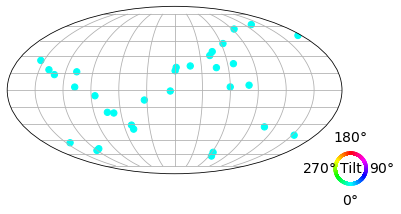

In [12]:
visualize_so3_probabilities(
    jax.vmap(lambda x: SO3(x).as_matrix())(batch['x']),
    0.01);

In [30]:

model_head = ImplicitSO3(1, 1, [256,256,256,256],
                              'random',
                              2**12,
                              100000)

In [31]:


######################   Load the datasets   ###############################

##########################  Optimizer  #####################################
optimizer = tf.keras.optimizers.get('Adam')
learning_rate = 1e-5
optimizer.learning_rate = learning_rate
#########################  Logging setup  ##################################
train_loss = tf.keras.metrics.Mean('train_loss', dtype=tf.float32)

log_dir = os.path.join('./', 'logs')
train_summary_writer = tf.summary.create_file_writer(log_dir)


def cosine_decay(step, warmup_steps=1000):
    warmup_factor = min(step, warmup_steps) / warmup_steps
    decay_step = max(step - warmup_steps, 0) / (
        number_training_iterations - warmup_steps)
    return learning_rate * warmup_factor * (1 + tf.cos(decay_step * np.pi)) / 2

@tf.function
def train_step( model_head, optimizer, rotations_gt):
    with tf.GradientTape() as tape:
        
        loss = model_head.compute_loss( rotations_gt)
        
    grads = tape.gradient(loss, model_head.trainable_variables)
    optimizer.apply_gradients( zip(grads, model_head.trainable_variables))
    return loss




In [32]:
from tqdm import tqdm
import haiku as hk
rng_seq = hk.PRNGSequence(42)

In [33]:

number_training_iterations = 10_000
for step in tqdm(range( number_training_iterations)):
    step_num = optimizer.iterations.numpy()
    if step_num > number_training_iterations:
      break

    tf.keras.backend.set_value(optimizer.learning_rate,
                               cosine_decay(step_num))
    
    #batch = get_batch(next(dset), next(rng_seq))
    rotations_gt = next(dset)['pos_mat']

    loss = train_step( model_head, optimizer, rotations_gt)

    train_loss(loss)

    

    if (step_num) % 100 == 0:
      avg_loss = train_loss.result()
      train_loss.reset_states()
      with train_summary_writer.as_default():
        tf.summary.scalar('loss', avg_loss, step=step_num)
        tf.summary.scalar(
            'learning_rate', optimizer.learning_rate, step=step_num)
      logging.info('Step %d, training loss=%.2f', step_num, avg_loss)

  0%|          | 0/10000 [00:00<?, ?it/s]

Tensor("rotation_matrix_3d_from_quaternion/Reshape:0", shape=(4096, 3, 3), dtype=float32)
Tensor("rotation_matrix_3d_from_quaternion/Reshape:0", shape=(4096, 3, 3), dtype=float32)


100%|██████████| 10000/10000 [03:23<00:00, 49.06it/s]


In [34]:
tf.summary

<module 'tensorboard.summary._tf.summary' from '/jet/home/yjagvara/.local/lib/python3.7/site-packages/tensorboard/summary/_tf/summary/__init__.py'>

In [94]:
a,b = model_head.output_pdf( num_queries=500_000 )

In [95]:
model_head.predict_rotation()

<tf.Tensor: shape=(1, 3, 3), dtype=float32, numpy=
array([[[ 5.0000000e-01,  8.3651632e-01, -2.2414386e-01],
        [-7.6376623e-01,  5.4794174e-01,  3.4120527e-01],
        [ 4.0824154e-01,  5.9087825e-04,  9.1287374e-01]]], dtype=float32)>

In [96]:
b

<tf.Tensor: shape=(294912,), dtype=float32, numpy=
array([5.3412603e-18, 6.0044091e-23, 1.7008625e-20, ..., 3.5983329e-22,
       4.6040583e-22, 3.6728680e-18], dtype=float32)>

/opt/packages/AI/anaconda3-tf2.2020.11/lib/python3.7/site-packages/ipykernel/__main__.py:93: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
/opt/packages/AI/anaconda3-tf2.2020.11/lib/python3.7/site-packages/ipykernel/__main__.py:98: UserWarning: FixedFormatter should only be used together with FixedLocator


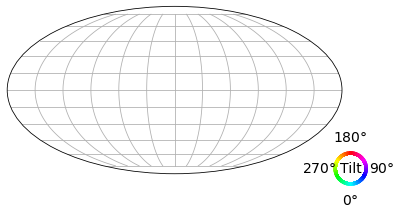

In [97]:
visualize_so3_probabilities_cut((a),
    b, display_threshold_probability=0.001);

In [98]:
sum(b)

1.0000002

In [99]:
b.numpy()

array([5.3412603e-18, 6.0044091e-23, 1.7008625e-20, ..., 3.5983329e-22,
       4.6040583e-22, 3.6728680e-18], dtype=float32)

In [108]:
rand_idx = np.random.choice( len(a), size= 500_000, replace=True, p=b.numpy() )

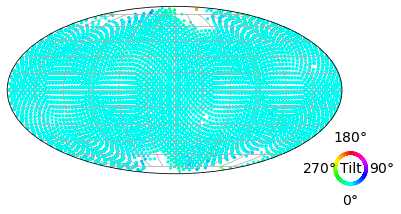

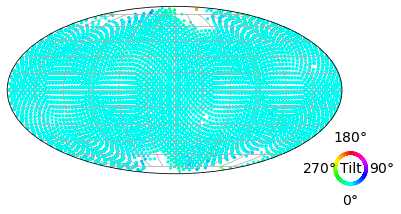

In [109]:
visualize_so3_probabilities (a[rand_idx])

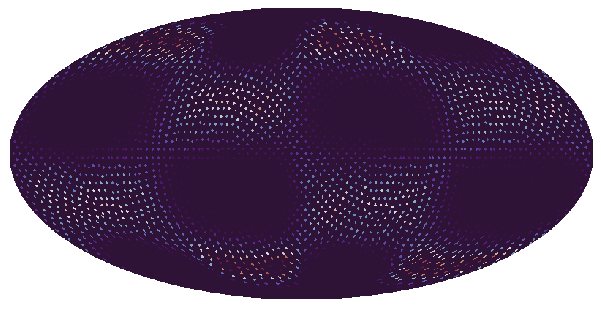

In [111]:
visualize_so3_density(a[rand_idx] , 50)

In [113]:
a[rand_idx].shape

(500000, 3, 3)

In [117]:
with open( "./checkerboard_ipdf_500_000.npy", "wb") as f:
        np.save(f, a[rand_idx])

In [103]:
def visualize_so3_probabilities_cut(rotations,
                                probabilities=None,
                                rotations_gt=None,
                                ax=None,
                                fig=None, display_threshold_probability=0.0,
                                show_color_wheel=True,
                                canonical_rotation=np.eye(3)):
  """Plot a single distribution on SO(3) using the tilt-colored method.
  Args:
    rotations: [N, 3, 3] tensor of rotation matrices
    probabilities: [N] tensor of probabilities
    rotations_gt: [N_gt, 3, 3] or [3, 3] ground truth rotation matrices
    ax: The matplotlib.pyplot.axis object to paint
    fig: The matplotlib.pyplot.figure object to paint
    show_color_wheel: If True, display the explanatory color wheel which matches
      color on the plot with tilt angle
    canonical_rotation: A [3, 3] rotation matrix representing the 'display
      rotation', to change the view of the distribution.  It rotates the
      canonical axes so that the view of SO(3) on the plot is different, which
      can help obtain a more informative view.
  Returns:
    A matplotlib.pyplot.figure object, or a tensor of pixels if to_image=True.
  """
  def _show_single_marker(ax, rotation, marker, edgecolors=True,
                          facecolors=False):
    eulers = SO3.from_matrix(rotation).as_rpy_radians()
    xyz = rotation[:, 0]
    tilt_angle = eulers[0]
    longitude = np.arctan2(xyz[0], -xyz[1])
    latitude = np.arcsin(xyz[2])

    color = cmap(0.5 + tilt_angle / 2 / np.pi)
    ax.scatter(longitude, latitude, s=2500,
               edgecolors=color if edgecolors else 'none',
               facecolors=facecolors if facecolors else 'none',
               marker=marker,
               linewidth=4)

  if ax is None:
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='mollweide')
  if rotations_gt is not None and len(rotations_gt.shape) == 2:
    rotations_gt = jnp.expand_dims(rotations_gt,axis=0)

  display_rotations = rotations @ canonical_rotation
  cmap = plt.cm.hsv
  scatterpoint_scaling = 4e3
  eulers_queries = jax.vmap(lambda x: SO3.from_matrix(x).as_rpy_radians())(display_rotations)
  xyz = display_rotations[:, :, 0]
  tilt_angles = eulers_queries.roll

  longitudes = np.arctan2(xyz[:, 0], -xyz[:, 1])
  latitudes = np.arcsin(xyz[:, 2])

  which_to_display = (probabilities > display_threshold_probability)

  if rotations_gt is not None:
    # The visualization is more comprehensible if the GT
    # rotation markers are behind the output with white filling the interior.
    display_rotations_gt = rotations_gt @ canonical_rotation

    for rotation in display_rotations_gt:
      _show_single_marker(ax, rotation, 'o')
    # Cover up the centers with white markers
    for rotation in display_rotations_gt:
      _show_single_marker(ax, rotation, 'o', edgecolors=False,
                          facecolors='#ffffff')

  # Display the distribution
  if probabilities is None:
    probabilities = jnp.ones_like(longitudes)*0.001
  


    
  ax.scatter(
      longitudes[which_to_display],
      latitudes[which_to_display],
      s=scatterpoint_scaling * probabilities[which_to_display],
      c=cmap(0.5 + tilt_angles[np.array(which_to_display)] / 2. / np.pi))

  ax.grid()
  ax.set_xticklabels([])
  ax.set_yticklabels([])

  if show_color_wheel:
    # Add a color wheel showing the tilt angle to color conversion.
    ax = fig.add_axes([0.86, 0.17, 0.12, 0.12], projection='polar')
    theta = np.linspace(-3 * np.pi / 2, np.pi / 2, 200)
    radii = np.linspace(0.4, 0.5, 2)
    _, theta_grid = np.meshgrid(radii, theta)
    colormap_val = 0.5 + theta_grid / np.pi / 2.
    ax.pcolormesh(theta, radii, colormap_val.T, cmap=cmap)
    ax.set_yticklabels([])
    ax.set_xticklabels([r'90$\degree$', None,
                        r'180$\degree$', None,
                        r'270$\degree$', None,
                        r'0$\degree$'], fontsize=14)
    ax.spines['polar'].set_visible(False)
    plt.text(0.5, 0.5, 'Tilt', fontsize=14,
             horizontalalignment='center',
             verticalalignment='center', transform=ax.transAxes)
  plt.show()
  return fig